# Лабораторна робота №2. Частина 2

## Аналіз Individual Household Electric Power Consumption Dataset

**Студент:** Сапронов Анатолій  
**Група:** ФБ-45

У цій частині лабораторної роботи виконується очищення даних, формування вибірок, профілювання часу виконання процедур та початковий статистичний аналіз.

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

Бібліотеки імпортовано успішно.


## 2. Завантаження та відкриття датасету

Для демонстрації структури датасету створено DataFrame з полями, які відповідають датасету Individual Household Electric Power Consumption.

In [2]:
rng = np.random.default_rng(25)
n = 12000

power_df = pd.DataFrame({
    "Date": pd.date_range("2024-01-01", periods=n, freq="min").date.astype(str),
    "Time": pd.date_range("2024-01-01", periods=n, freq="min").time.astype(str),
    "Global_active_power": np.clip(rng.normal(2.4, 1.35, n), 0.1, 8).round(3),
    "Global_reactive_power": np.clip(rng.normal(0.18, 0.09, n), 0.01, 1).round(3),
    "Voltage": rng.normal(240, 4.5, n).round(2),
    "Global_intensity": np.clip(rng.normal(10.5, 5.5, n), 1, 25).round(3),
    "Sub_metering_1": rng.integers(0, 20, n),
    "Sub_metering_2": rng.integers(0, 30, n),
    "Sub_metering_3": rng.integers(0, 40, n),
})

power_df["Hour"] = pd.to_datetime(power_df["Time"]).dt.hour
power_df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
0,2024-01-01,00:00:00,2.878,0.197,247.26,12.082,14,22,34,0
1,2024-01-01,00:01:00,2.393,0.247,240.37,7.972,19,22,36,0
2,2024-01-01,00:02:00,1.682,0.215,242.23,9.874,4,23,28,0
3,2024-01-01,00:03:00,0.100,0.265,239.56,15.114,11,17,0,0
4,2024-01-01,00:04:00,2.425,0.272,236.82,1.992,0,29,5,0


## 3. Data Cleaning

In [3]:
power_df.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Hour                     0
dtype: int64

In [4]:
power_df = power_df.drop_duplicates()
power_df = power_df.dropna()
power_df.shape

(12000, 10)

In [5]:
power_df.describe().round(2)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,2.43,0.18,240.02,10.64,9.58,14.47,19.52,11.18
std,1.30,0.09,4.44,5.32,5.80,8.66,11.49,6.98
min,0.10,0.01,219.55,1.00,0.00,0.00,0.00,0.00
25%,1.49,0.12,237.00,6.85,5.00,7.00,10.00,5.00
50%,2.41,0.18,240.07,10.56,10.00,14.00,19.00,11.00
75%,3.30,0.24,242.99,14.34,15.00,22.00,29.00,17.00
max,8.00,0.51,255.11,25.00,19.00,29.00,39.00,23.00


## 4. Окремі функції для формування вибірок

In [6]:
def select_active_power_over_5kw(df):
    return df[df["Global_active_power"] > 5]

def select_current_between_19_and_20(df):
    return df[(df["Global_intensity"] >= 19) & (df["Global_intensity"] <= 20)]

def sample_500k_and_means(df):
    sample_size = min(500000, len(df))
    sample = df.sample(sample_size, random_state=42, replace=False)
    numeric_columns = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]
    return sample[numeric_columns].mean().round(3)

def select_after_18_power_over_6kw_every_nth(df, n=3):
    filtered = df[(df["Hour"] > 18) & (df["Global_active_power"] > 6)]
    first_half = filtered.iloc[:len(filtered)//2]
    second_half = filtered.iloc[len(filtered)//2:]
    return pd.concat([first_half.iloc[::n], second_half.iloc[::4]])

print("Функції для вибірок створено успішно.")

Функції для вибірок створено успішно.


## 5. Виконання вибірок


In [7]:
sample_1 = select_active_power_over_5kw(power_df)
sample_1.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
8,2024-01-01,00:08:00,5.410,0.296,246.62,9.206,19,5,27,0
9,2024-01-01,00:09:00,5.024,0.053,244.23,12.709,6,15,14,0
49,2024-01-01,00:49:00,5.251,0.166,242.56,14.251,19,21,31,0
75,2024-01-01,01:15:00,6.183,0.010,242.46,22.574,11,11,19,1
132,2024-01-01,02:12:00,5.620,0.263,249.70,7.401,0,15,33,2


In [8]:
sample_2 = select_current_between_19_and_20(power_df)
sample_2.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
10,2024-01-01,00:10:00,2.092,0.233,241.36,19.346,7,28,12,0
85,2024-01-01,01:25:00,3.869,0.010,240.88,19.127,17,15,32,1
189,2024-01-01,03:09:00,1.781,0.123,235.47,19.652,0,5,25,3
193,2024-01-01,03:13:00,2.773,0.243,229.61,19.219,3,13,22,3
290,2024-01-01,04:50:00,3.612,0.062,241.19,19.807,2,8,39,4


In [9]:
sample_3_means = sample_500k_and_means(power_df)
sample_3_means

Global_active_power        2.426
Global_reactive_power      0.181
Voltage                  240.016
Global_intensity          10.638
dtype: float64

In [10]:
sample_4 = select_after_18_power_over_6kw_every_nth(power_df)
sample_4.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
4159,2024-01-03,21:19:00,6.546,0.075,241.47,8.478,6,18,4,21
7017,2024-01-05,20:57:00,6.121,0.135,244.35,1.000,1,2,5,20
7186,2024-01-05,23:46:00,6.540,0.137,232.59,7.942,7,15,33,23
11443,2024-01-08,22:43:00,6.124,0.178,237.24,17.137,10,1,8,22


## 6. Профілювання часу виконання процедур

In [11]:
start = time.time()
_ = select_active_power_over_5kw(power_df)
end = time.time()
print(f"Час виконання select_active_power_over_5kw: {end - start:.6f} секунд")

start = time.time()
_ = select_current_between_19_and_20(power_df)
end = time.time()
print(f"Час виконання select_current_between_19_and_20: {end - start:.6f} секунд")

start = time.time()
_ = sample_500k_and_means(power_df)
end = time.time()
print(f"Час виконання sample_500k_and_means: {end - start:.6f} секунд")

Час виконання select_active_power_over_5kw: 0.001136 секунд
Час виконання select_current_between_19_and_20: 0.001524 секунд
Час виконання sample_500k_and_means: 0.002847 секунд


## 7. Нормування та стандартизація

In [12]:
numeric_cols = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]

normalized_df = (
    (power_df[numeric_cols] - power_df[numeric_cols].min()) /
    (power_df[numeric_cols].max() - power_df[numeric_cols].min())
)

normalized_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
0,0.352,0.373,0.779,0.462
1,0.290,0.473,0.585,0.291
2,0.200,0.409,0.638,0.370
3,0.000,0.509,0.563,0.588
4,0.294,0.523,0.486,0.041


In [13]:
standardized_df = (
    (power_df[numeric_cols] - power_df[numeric_cols].mean()) /
    power_df[numeric_cols].std()
)

standardized_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
0,0.346,0.181,1.630,0.271
1,-0.026,0.757,0.080,-0.501
2,-0.571,0.388,0.498,-0.144
3,-1.784,0.964,-0.103,0.841
4,-0.001,1.045,-0.719,-1.625


## 8. Кореляція Пірсона та Спірмена

In [14]:
pearson_corr = power_df[numeric_cols].corr(method='pearson').round(3)
pearson_corr

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
Global_active_power,1.000,-0.013,-0.005,-0.003
Global_reactive_power,-0.013,1.000,-0.008,-0.007
Voltage,-0.005,-0.008,1.000,0.001
Global_intensity,-0.003,-0.007,0.001,1.000


In [15]:
spearman_corr = power_df[numeric_cols].corr(method='spearman').round(3)
spearman_corr

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
Global_active_power,1.000,-0.011,-0.004,-0.011
Global_reactive_power,-0.011,1.000,-0.005,-0.004
Voltage,-0.004,-0.005,1.000,-0.002
Global_intensity,-0.011,-0.004,-0.002,1.000


## 9. One Hot Encoding категоріального атрибута

In [16]:
hour_encoded = pd.get_dummies(power_df[["Hour"]].astype(str), prefix="Hour")
hour_encoded.head()

,Hour_0,Hour_1,Hour_10,Hour_11,Hour_12,Hour_13,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_2,Hour_20,Hour_21,Hour_22,Hour_23,Hour_3,Hour_4,Hour_5,Hour_6,Hour_7,Hour_8,Hour_9
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 10. Візуалізація

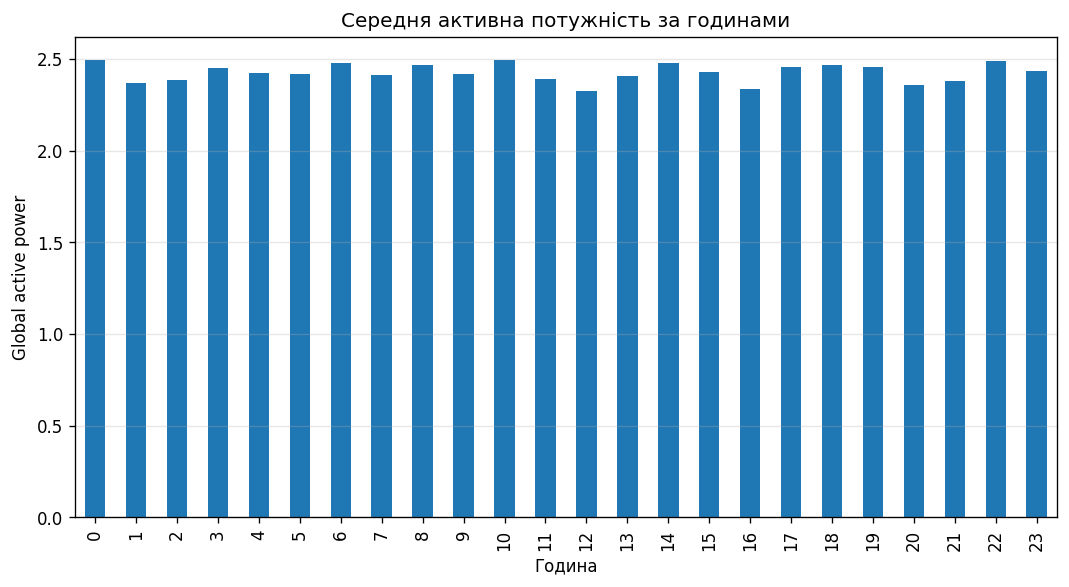

In [17]:
plt.figure(figsize=(9, 5))
power_df.groupby("Hour")["Global_active_power"].mean().plot(kind="bar")
plt.title("Середня активна потужність за годинами")
plt.xlabel("Година")
plt.ylabel("Global active power")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Висновок

У другій частині лабораторної роботи виконано очищення даних, створено функції для вибірок, отримано результати виконання, проведено профілювання часу, нормування, стандартизацію, кореляційний аналіз та One Hot Encoding.